# Fig 1: Plots for Target Enrichment Metrics and Probe Expansion

## Preprocessing
- Target enrichment metrics are calculated using Picard CollectHsMetrics

```bash
#!/bin/bash

# Create directories if they don't exist
mkdir -p hs_metrics

# Process TW1nt12k probe
for f in /home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_TW1nt12k_500targets_minqual0_minreads10/mapping/bam/*.sorted.bam; do
    fbname=$(basename "$f" .sorted.bam)
    echo "$fbname"

    picard CollectHsMetrics \
        --INPUT "$f" \
        --OUTPUT hs_metrics/"${fbname}"_hs_metrics_TW_hg38_1nt15-50bp_12472probes.txt \
        --BAIT_INTERVALS /home/tcheng/software/RETrace2/resources/picard_interval_list/hg38/RETrace.hg38.1nt15-50bp.12472probes.Picard.interval_list \
        --TARGET_INTERVALS /home/tcheng/software/RETrace2/resources/picard_interval_list/hg38/RETrace.hg38.1nt15-50bp.12472probes.Picard.interval_list || exit 1
done

# Process CA2nt24k probe
for f in /home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_CA2nt24k_500targets_minqual0_minreads10/mapping/bam/*.sorted.bam; do
    fbname=$(basename "$f" .sorted.bam)
    echo "$fbname"

    picard CollectHsMetrics \
        --INPUT "$f" \
        --OUTPUT hs_metrics/"${fbname}"_hs_metrics_CA_hg38_2-6nt_24000probes.txt \
        --BAIT_INTERVALS /home/tcheng/software/RETrace2/resources/picard_interval_list/hg38/RETrace.hg38.2-6nt.24000probes.Picard.interval_list \
        --TARGET_INTERVALS /home/tcheng/software/RETrace2/resources/picard_interval_list/hg38/RETrace.hg38.2-6nt.24000probes.Picard.interval_list || exit 1
done

```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

## Parameters

In [2]:
hs_path_dc = {'\nRETrace v1\n20210920':glob.glob("/home/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/target_enrichment/hs_metrics/*CA_hg38_2-6nt*.txt"),
              '\nRETrace v2\n20240319':glob.glob("/home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/target_enrichment/hs_metrics/*_1nt10-30bp*.txt")
}

## Read Table

In [3]:
def get_metric_df(path):
    '''Take the path of PiCard CollectHsMetrics ouput .txt file and generate a consie dataframe with most useful info'''

    text = pd.read_csv(path)
    metric = text.iloc[4,0].split("\t")
    result = text.iloc[5,0].split("\t")
    df = pd.DataFrame({'metric':metric, 'result':result})
    
    return(df)

In [4]:
# read raw output
hs_raw_dfs_dc = {k:[get_metric_df(p) for p in p_list] for k, p_list in hs_path_dc.items()}

# select most useful info: on bait, exclude target
hs_dfs_dc = {k:[df.iloc[np.r_[:13, 20:57],] for df in df_list] for k, df_list in hs_raw_dfs_dc.items()}

In [5]:
# look at one example output
hs_dfs_dc['\nRETrace v1\n20210920'][0]

,metric,result
0,BAIT_SET,RETrace
1,BAIT_TERRITORY,393536
2,BAIT_DESIGN_EFFICIENCY,1
3,ON_BAIT_BASES,98786624
4,NEAR_BAIT_BASES,247308761
5,OFF_BAIT_BASES,817909232
6,PCT_SELECTED_BASES,0.297332
7,PCT_OFF_BAIT,0.702668
8,ON_BAIT_VS_SELECTED,0.285432
9,MEAN_BAIT_COVERAGE,251.023093


# Plot % on target

In [6]:
# build df for violin plot
probe_ls = []
on_target = []

for k, df_list in hs_dfs_dc.items():
    for df in df_list:
        probe_ls.append(k)
        on_target.append(round(float(df.iloc[6,1])*100, 2))
        
data = pd.DataFrame({'probe':probe_ls, 'on_target': on_target})
data.head()

,probe,on_target
0,\nRETrace v1\n20210920,29.73
1,\nRETrace v1\n20210920,38.30
2,\nRETrace v1\n20210920,29.99
3,\nRETrace v1\n20210920,28.53
4,\nRETrace v1\n20210920,29.50


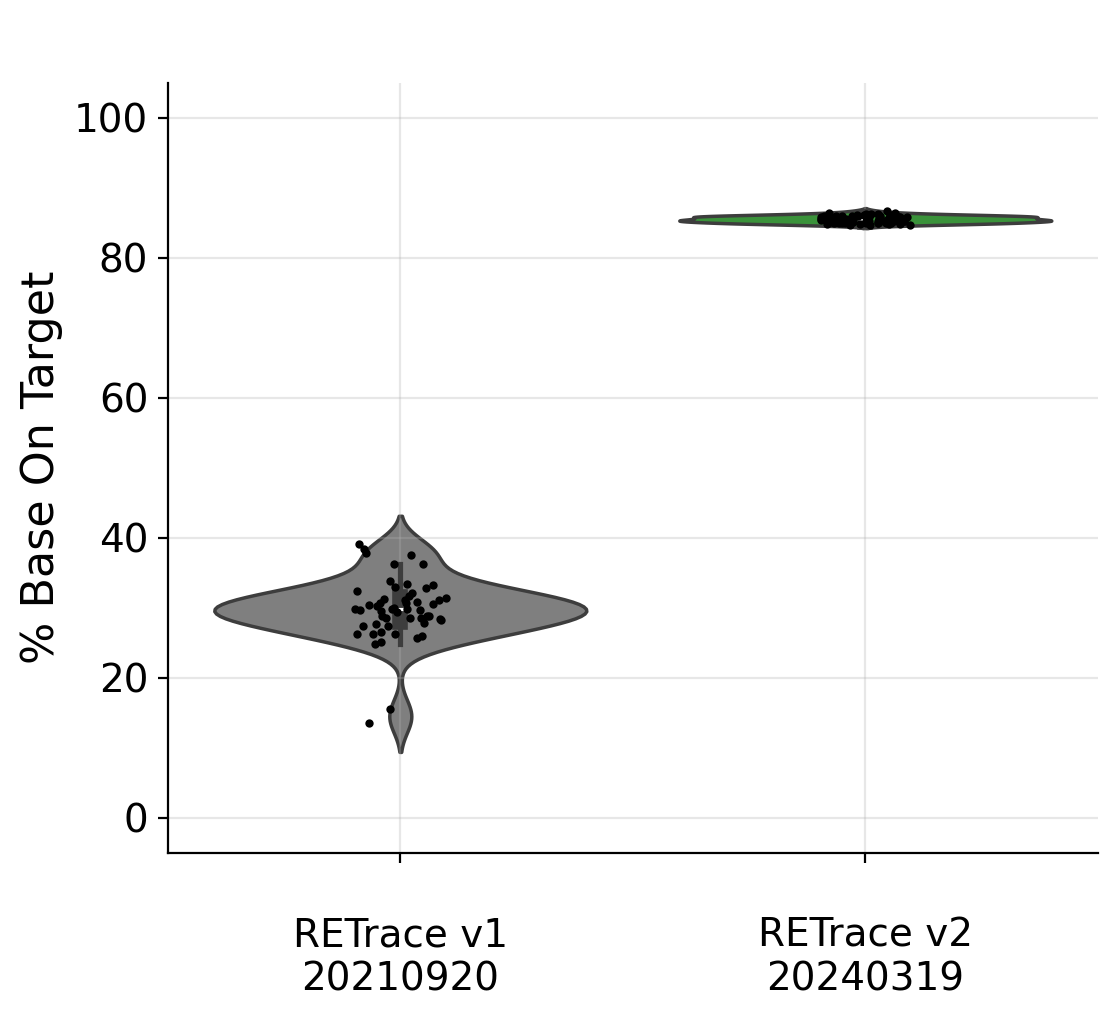

In [7]:
fig, ax = plt.subplots(figsize=(6,5), dpi=200)

sns.violinplot(x='probe', y='on_target', data=data, hue='probe', palette=['tab:gray', 'tab:green'])
sns.stripplot(x="probe", y="on_target", data=data, color="black", ax=ax, size=3)

ax.set_xlabel("")
ax.set_title(" ", fontsize=22)
ax.set_ylabel('% Base On Target', fontsize=16)

ax.tick_params(axis='both', labelsize=14)

# Get unique values from 'probe' column
unique_probes = data['probe'].unique()

# Set the tick locations and labels
ax.set_xticks(range(len(unique_probes)))

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(-5,105)

plt.show()

## Stats

In [8]:
data.groupby(["probe"]).describe().transpose()

probe            \nRETrace v1\n20210920  \nRETrace v2\n20240319
on_target count               54.000000               72.000000
          mean                29.760926               85.480556
          std                  4.520196                0.471915
          min                 13.450000               84.600000
          25%                 27.877500               85.150000
          50%                 29.740000               85.440000
          75%                 31.565000               85.855000
          max                 39.040000               86.660000

# Plot % Target covered at different depth

In [9]:
# build df for violin plot
probe_ls = []
perc_target = []

for k, df_list in hs_dfs_dc.items():
    for df in df_list:
        probe_ls += [k] * 5
        df.index = df.metric
        perc_target += [round(float(x)*100, 1) for x in df.loc[["PCT_TARGET_BASES_1X", "PCT_TARGET_BASES_2X", "PCT_TARGET_BASES_10X",
                                                     "PCT_TARGET_BASES_30X", "PCT_TARGET_BASES_50X"],"result"]] 

data2 = pd.DataFrame({'probe': probe_ls,
                     'coverage_depth': ['1X', '2X', '10X', '30X', '50X']*int(len(probe_ls)/5),
                     'perc_target': perc_target})
data2.head()

,probe,coverage_depth,perc_target
0,\nRETrace v1\n20210920,1X,38.2
1,\nRETrace v1\n20210920,2X,29.7
2,\nRETrace v1\n20210920,10X,16.9
3,\nRETrace v1\n20210920,30X,12.6
4,\nRETrace v1\n20210920,50X,11.3


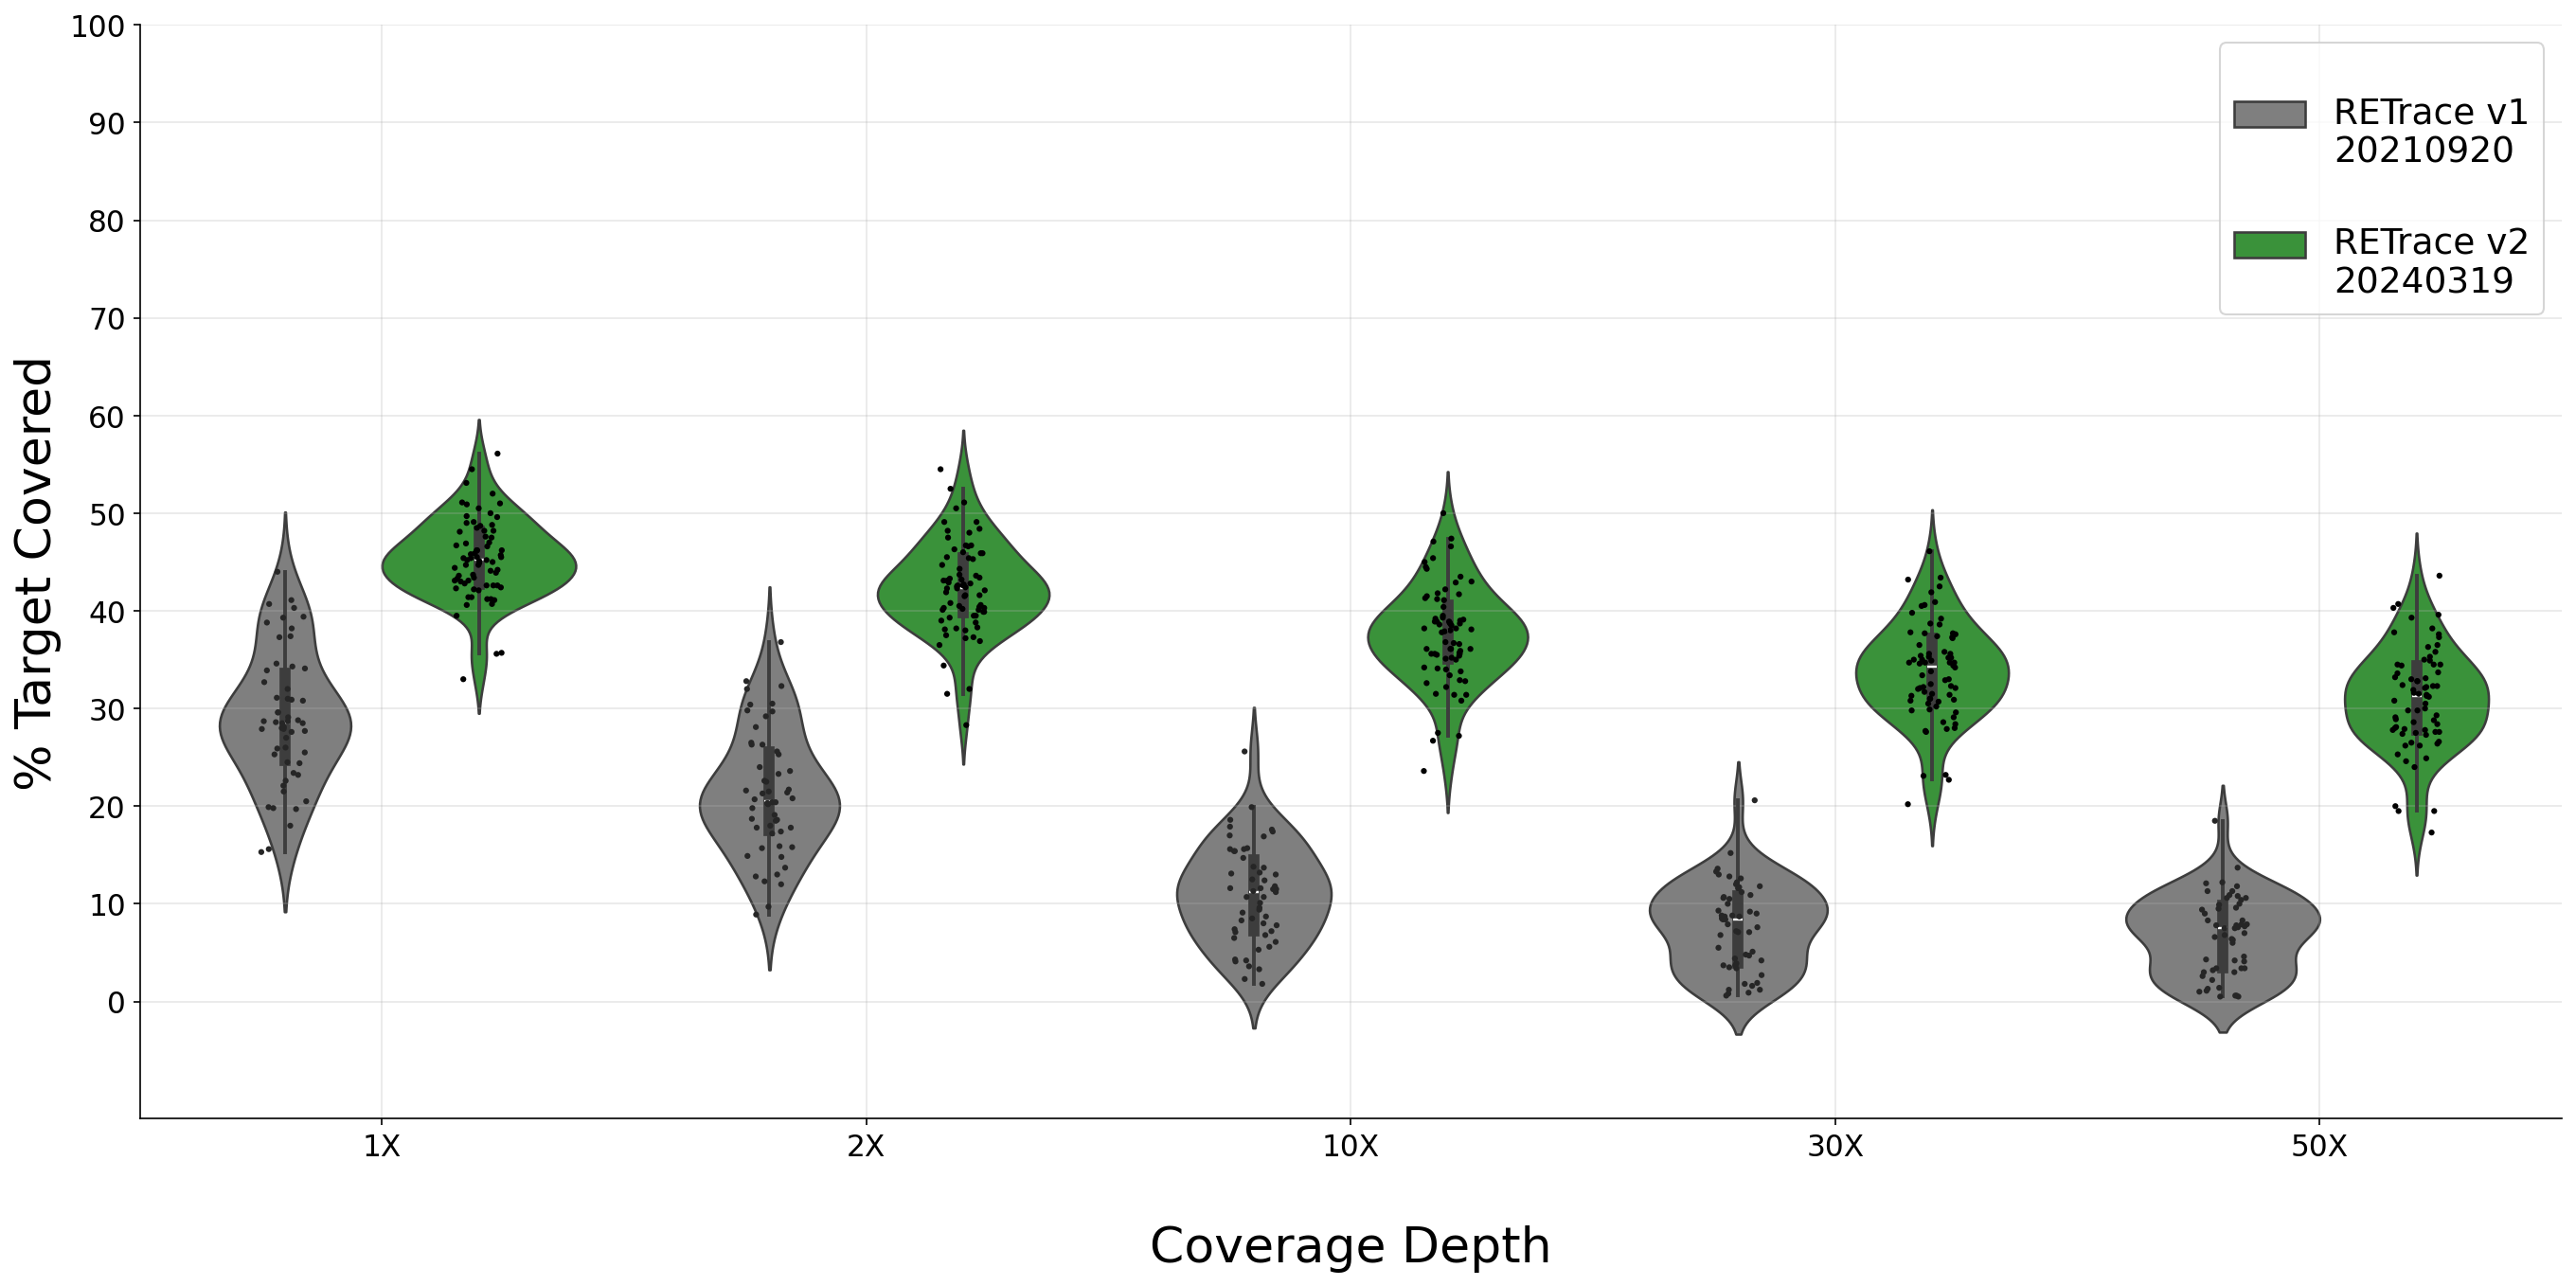

In [10]:
fig, ax = plt.subplots(figsize=(22,10), dpi=150)

sns.violinplot(x='coverage_depth', y='perc_target', data=data2, hue='probe', palette=['tab:gray', 'tab:green'])
sns.stripplot(x='coverage_depth', y='perc_target', data=data2, hue='probe', palette='dark:black', size=3, dodge=True)

ax.set_title("", fontsize=25)
ax.set_xlabel("\nCoverage Depth", fontsize=25)
ax.set_ylabel('% Target Covered', fontsize=25)
ax.tick_params(axis='both', labelsize=15)

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(-12,100)
ax.set_yticks(np.arange(0,101,10))

# remove legend label for dots
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], fontsize=18)


plt.show()

## Stats

In [11]:
data2.groupby(["coverage_depth", "probe"]).describe()

perc_target                             \
                                            count       mean       std   min   
coverage_depth probe                                                           
10X            \nRETrace v1\n20210920        54.0  10.962963  5.011056   1.8   
               \nRETrace v2\n20240319        72.0  37.561111  5.000494  23.6   
1X             \nRETrace v1\n20210920        54.0  29.062963  6.786899  15.3   
               \nRETrace v2\n20240319        72.0  45.316667  4.105647  33.0   
2X             \nRETrace v1\n20210920        54.0  21.307407  6.278080   8.9   
               \nRETrace v2\n20240319        72.0  42.316667  4.693598  28.3   
30X            \nRETrace v1\n20210920        54.0   7.692593  4.376690   0.6   
               \nRETrace v2\n20240319        72.0  33.787500  4.994530  20.2   
50X            \nRETrace v1\n20210920        54.0   6.803704  4.035735   0.5   
               \nRETrace v2\n20240319        72.0  30.941667  5.129170  17.3   

                                                                    
                                          25%    50%     75%   max  
coverage_depth probe                                                
10X            \nRETrace v1\n20210920   7.250  11.25  14.475  25.6  
               \nRETrace v2\n20240319  35.075  37.95  40.575  50.0  
1X             \nRETrace v1\n20210920  24.700  28.55  33.600  44.0  
               \nRETrace v2\n20240319  42.750  45.20  48.125  56.1  
2X             \nRETrace v1\n20210920  17.500  20.55  25.525  36.8  
               \nRETrace v2\n20240319  39.800  42.35  45.425  54.5  
30X            \nRETrace v1\n20210920   3.975   8.40  10.850  20.6  
               \nRETrace v2\n20240319  30.875  34.30  37.225  46.1  
50X            \nRETrace v1\n20210920   3.400   7.50   9.825  18.5  
               \nRETrace v2\n20240319  27.750  31.30  34.425  43.6

In [12]:
data3 = data2.query("coverage_depth == '10X'")
data3.head()

,probe,coverage_depth,perc_target
2,\nRETrace v1\n20210920,10X,16.9
7,\nRETrace v1\n20210920,10X,13.7
12,\nRETrace v1\n20210920,10X,14.7
17,\nRETrace v1\n20210920,10X,6.1
22,\nRETrace v1\n20210920,10X,11.2


/tmp/ipykernel_845183/1792486598.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend().set_visible(False)
/tmp/ipykernel_845183/1792486598.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend().set_visible(False)


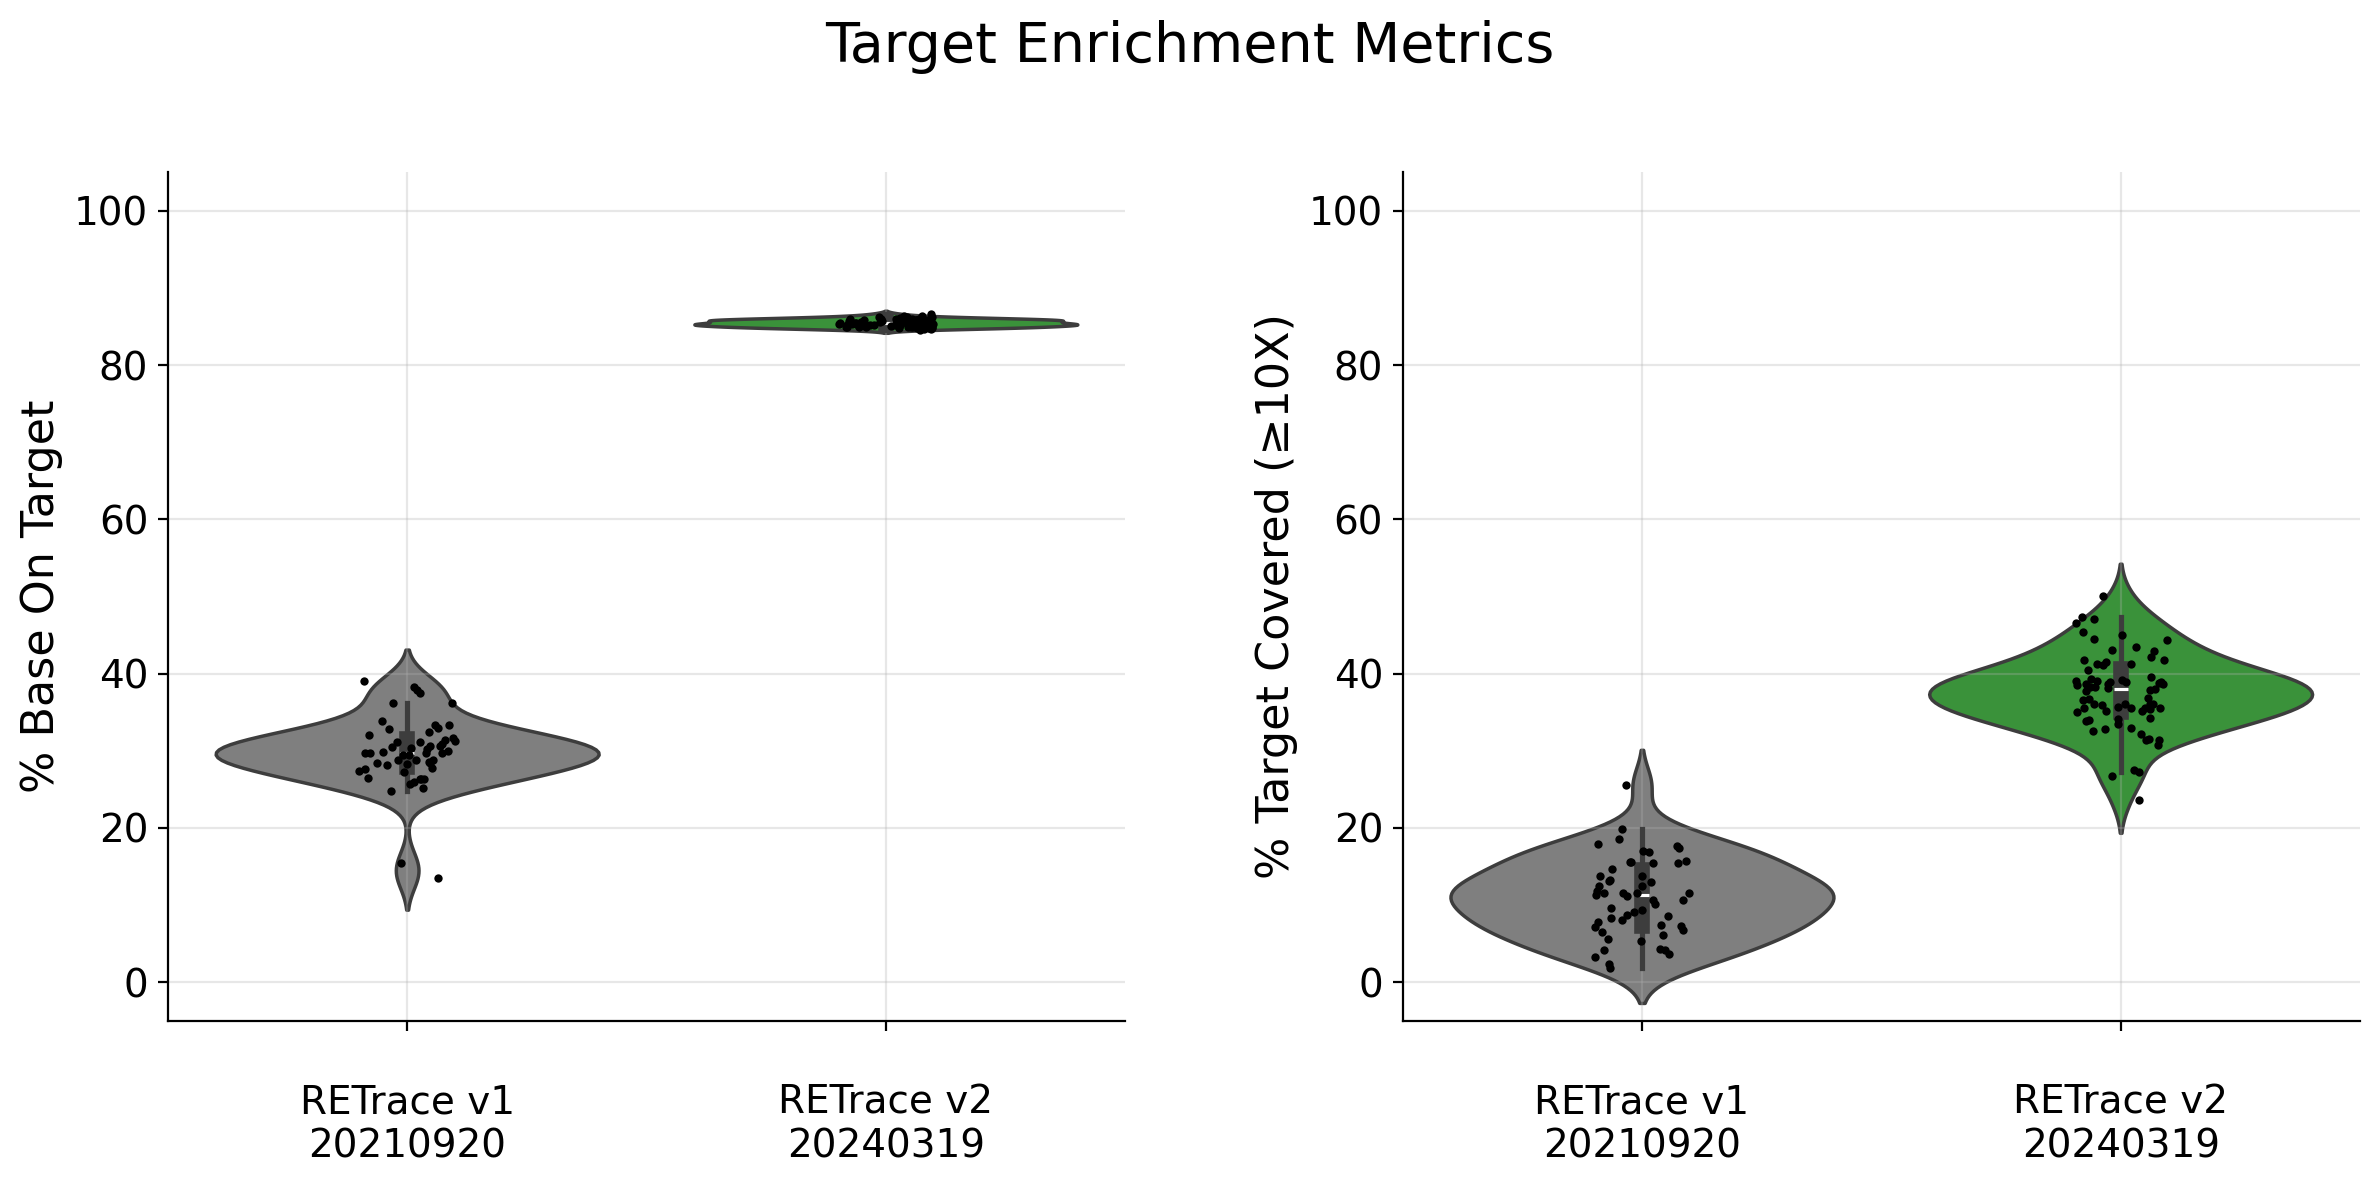

In [13]:
# Combined Plot - Side by Side
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)
fig.suptitle('Target Enrichment Metrics\n', fontsize=20)

# Left plot: % Base On Target
sns.violinplot(x='probe', y='on_target', data=data, hue='probe', palette=['tab:gray', 'tab:green'], ax=axes[0])
sns.stripplot(x="probe", y="on_target", data=data, color="black", ax=axes[0], size=3)

axes[0].set_xlabel("")
axes[0].set_ylabel('% Base On Target', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)

# Get unique values from 'probe' column
unique_probes = data['probe'].unique()
axes[0].set_xticks(range(len(unique_probes)))

axes[0].grid(True, alpha=0.3)
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)
axes[0].set_ylim(-5, 105)

# Right plot: % Target Covered at 10X
sns.violinplot(x='probe', y='perc_target', data=data3, hue='probe', palette=['tab:gray', 'tab:green'], ax=axes[1])
sns.stripplot(x="probe", y="perc_target", data=data3, color="black", ax=axes[1], size=3)

axes[1].set_xlabel("")
axes[1].set_ylabel('\n\n% Target Covered (≥10X)', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)

axes[1].set_xticks(range(len(unique_probes)))

axes[1].grid(True, alpha=0.3)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)
axes[1].set_ylim(-5, 105)

# Remove legends (since hue=probe is redundant with x=probe)
axes[0].legend().set_visible(False)
axes[1].legend().set_visible(False)

plt.tight_layout()
plt.savefig("Fig1_target_enrichment_metrics.pdf")
plt.show()


# Plot Probe Info

In [14]:
def count_lines(filename):
    with open(filename, 'r') as f:
        return sum(1 for line in f)

# N target can be calculated from target bed file
retrace1_n_targets = count_lines('/home/tcheng/software/RETrace2/resources/targets/hg38/RETrace.hg38.2-6nt.24000probes.bed')
retrace2_n_targets = count_lines('/home/tcheng/software/RETrace2/resources/targets/mm39/RETrace2.mm39.1nt10-30bp.92460targets169818probes.bed')

print(retrace1_n_targets, retrace2_n_targets)

11328 92460


In [15]:
probe_data = pd.DataFrame({'name':['\nRETrace v1\nDi- to Hexanucleotide', '\nRETrace v2\nHomopolymer'],
                           'n_target': [11328, 92460],
                           'n_probe': [24000, 169818]})

probe_data

,name,n_target,n_probe
0,\nRETrace v1\nDi- to Hexanucleotide,11328,24000
1,\nRETrace v2\nHomopolymer,92460,169818


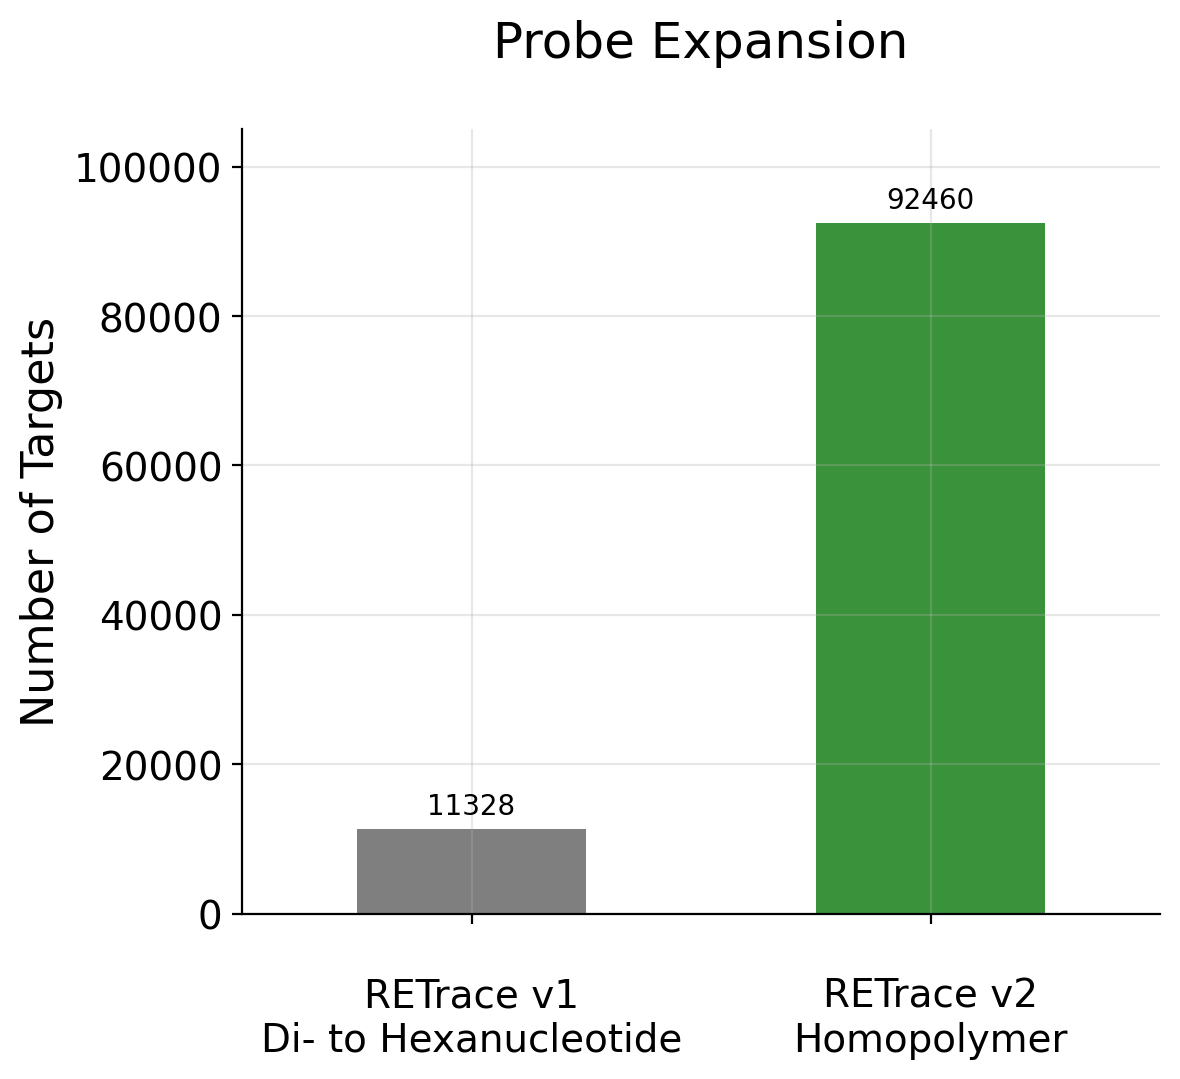

In [ ]:
fig, ax = plt.subplots(figsize=(6,5.5), dpi=200)

# plot n target
sns.barplot(data=probe_data, x='name', y='n_target', hue='name',palette=['tab:gray', 'tab:green'], width=0.5)

ax.set_title('Probe Expansion\n', fontsize=18)
ax.set_ylabel('Number of Targets', fontsize=16)
ax.tick_params(axis='both', labelsize=14)

ax.set_ylim(0,1e5+5000)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('')
ax.grid(True, alpha=0.3)

# add text
for i, n in enumerate(probe_data.n_target):
    ax.text(i, n+2000, n, ha='center')

plt.tight_layout()
plt.savefig("Fig1_probe_expansion.pdf")
plt.show()

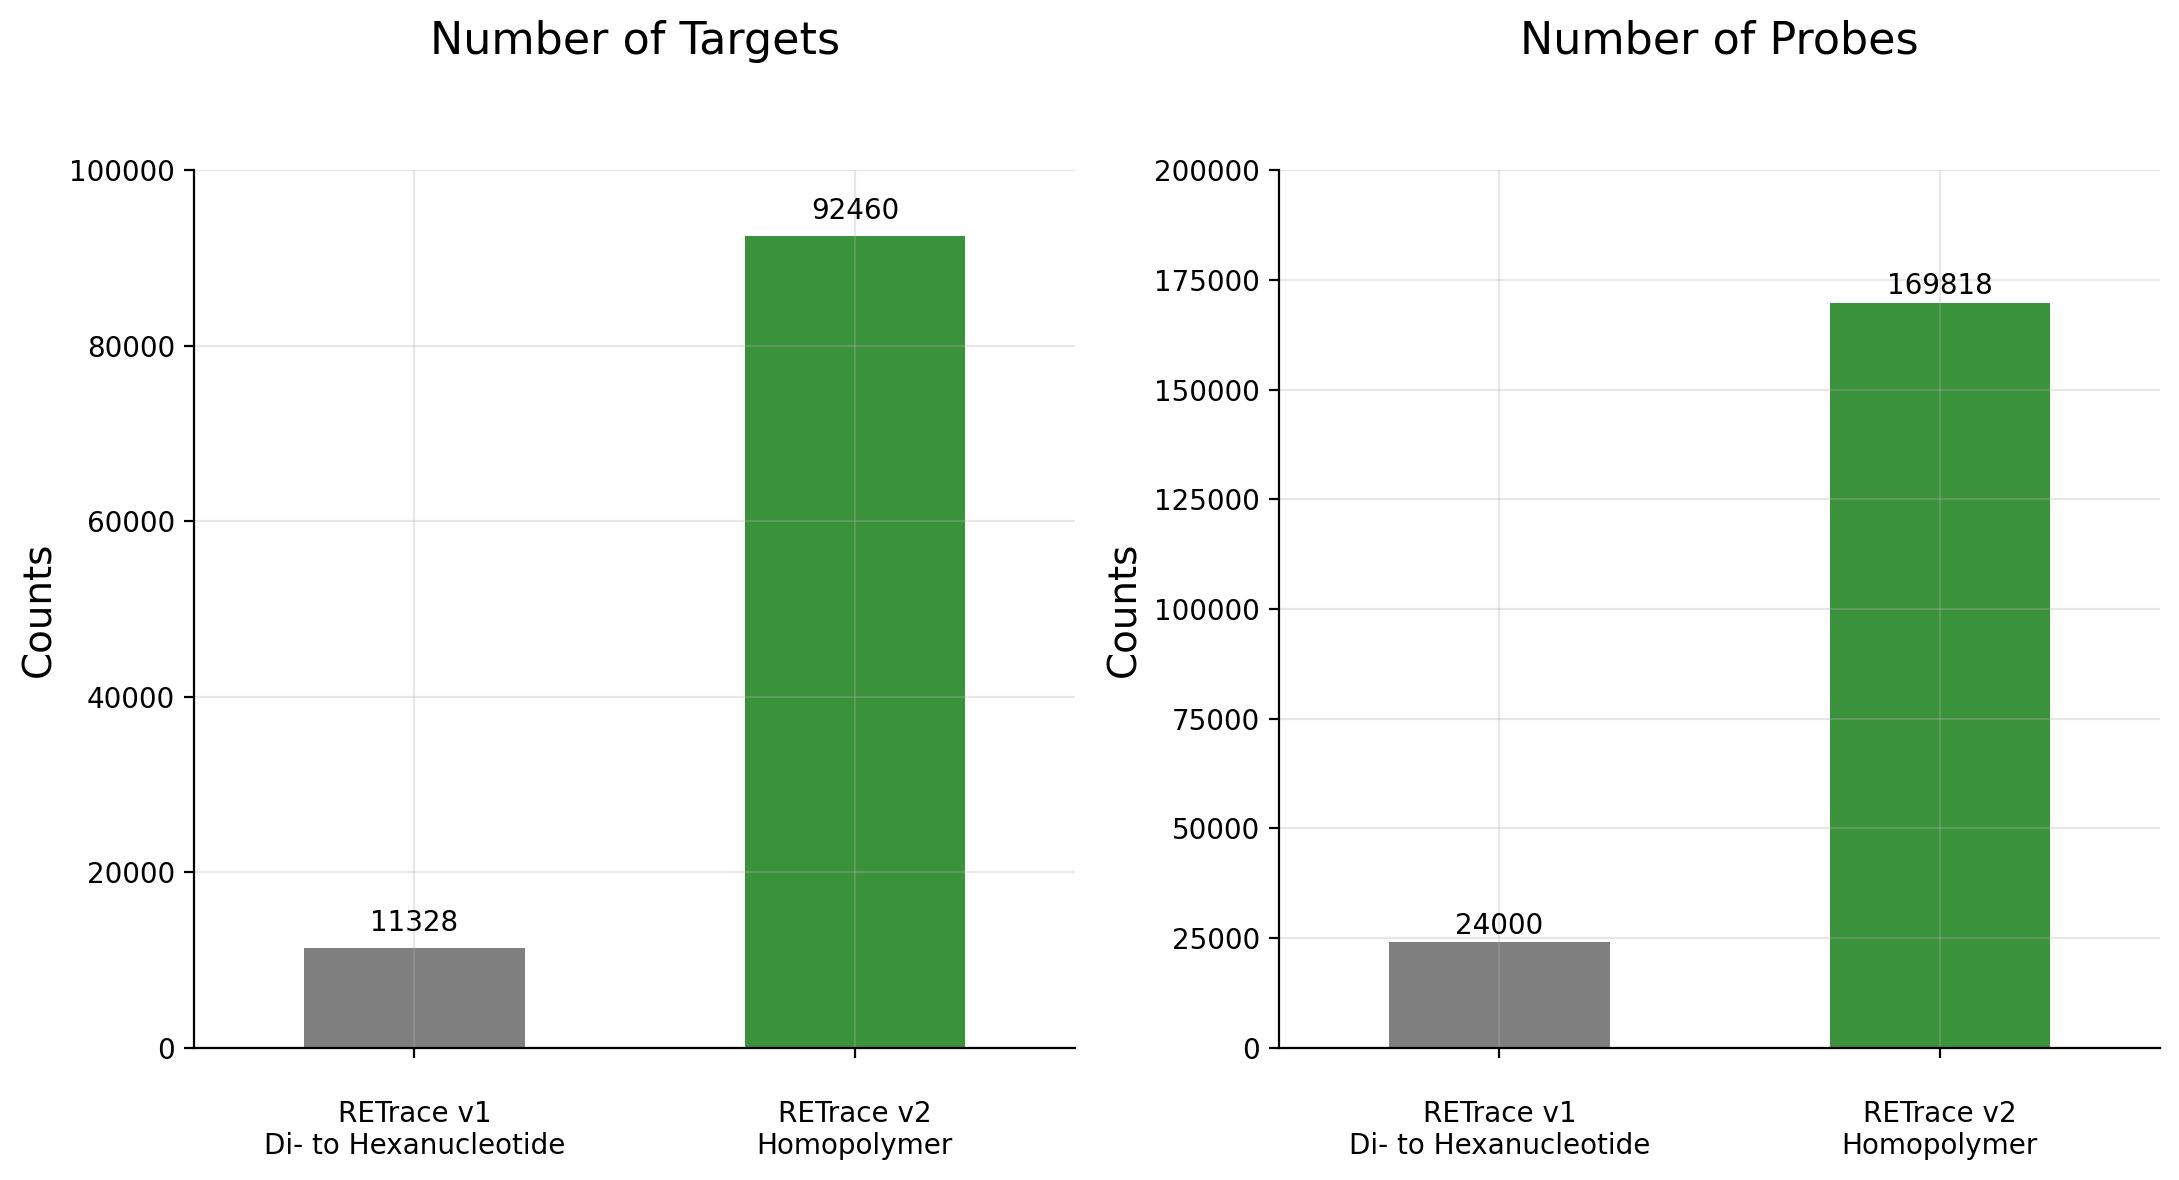

In [17]:
fig, ax = plt.subplots(figsize=(11,6), dpi=200, ncols=2)

# plot n target
sns.barplot(data=probe_data, x='name', y='n_target', ax=ax[0], hue='name', palette=['tab:gray', 'tab:green'], width=0.5)
# plot n probe
sns.barplot(data=probe_data, x='name', y='n_probe', ax=ax[1], hue='name', palette=['tab:gray', 'tab:green'], width=0.5)


ax[0].set_title('Number of Targets\n\n', fontsize=16)
ax[1].set_title('Number of Probes\n\n', fontsize=16)
ax[0].set_ylabel('Counts', fontsize=14)
ax[1].set_ylabel('Counts', fontsize=14)


for a in ax:
    a.set_ylim(0,2e5)
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(False)
    a.set_xlabel('')
    a.grid(True, alpha=0.3)

ax[0].set_ylim(0,1e5)

# add text
for i, n in enumerate(probe_data.n_target):
    ax[0].text(i, n+2000, n, ha='center')
for i, n in enumerate(probe_data.n_probe):
    ax[1].text(i, n+2000, n, ha='center')

plt.tight_layout()
plt.show()

# Plot N target per cell
- We use RETrace v1 20210920 and RETrace v2 20240319 library as examples

In [18]:
# read RETrace v1 20210920 stats
stats_data_v1 = pd.read_csv('/home/tcheng/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_CA2nt24k_500targets_minqual0_minreads10/stats/sample_stats.tsv', sep='\t')
stats_data_v1['group'] = ['\nRETrace v1\n20210920'] * stats_data_v1.shape[0]

In [19]:
# read RETrace v2 20240319 stats
stats_data_v2 = pd.read_csv('/home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/results_10000targets_3000cpgs_minqual0.9/stats/sample_stats.tsv', sep='\t')
stats_data_v2['group'] = ['\nRETrace v2\n20240319'] * stats_data_v2.shape[0]

In [20]:
# combine stats data
stats_data = pd.concat([stats_data_v1, stats_data_v2])
stats_data.head()

,sample_id,ms_targets_with_min_reads,cpg_count,pass,group
0,2-1-C4_3-7-G7_Plate2-1B,1232,0,True,\nRETrace v1\n20210920
1,2-1-C4_3-7-G7_Plate2-1C,1229,0,True,\nRETrace v1\n20210920
2,2-1-C4_3-7-G7_Plate2-1D,1052,0,True,\nRETrace v1\n20210920
3,2-1-C4_3-7-G7_Plate2-1E,1860,0,True,\nRETrace v1\n20210920
4,2-1-C4_3-7-G7_Plate2-1F,247,0,False,\nRETrace v1\n20210920


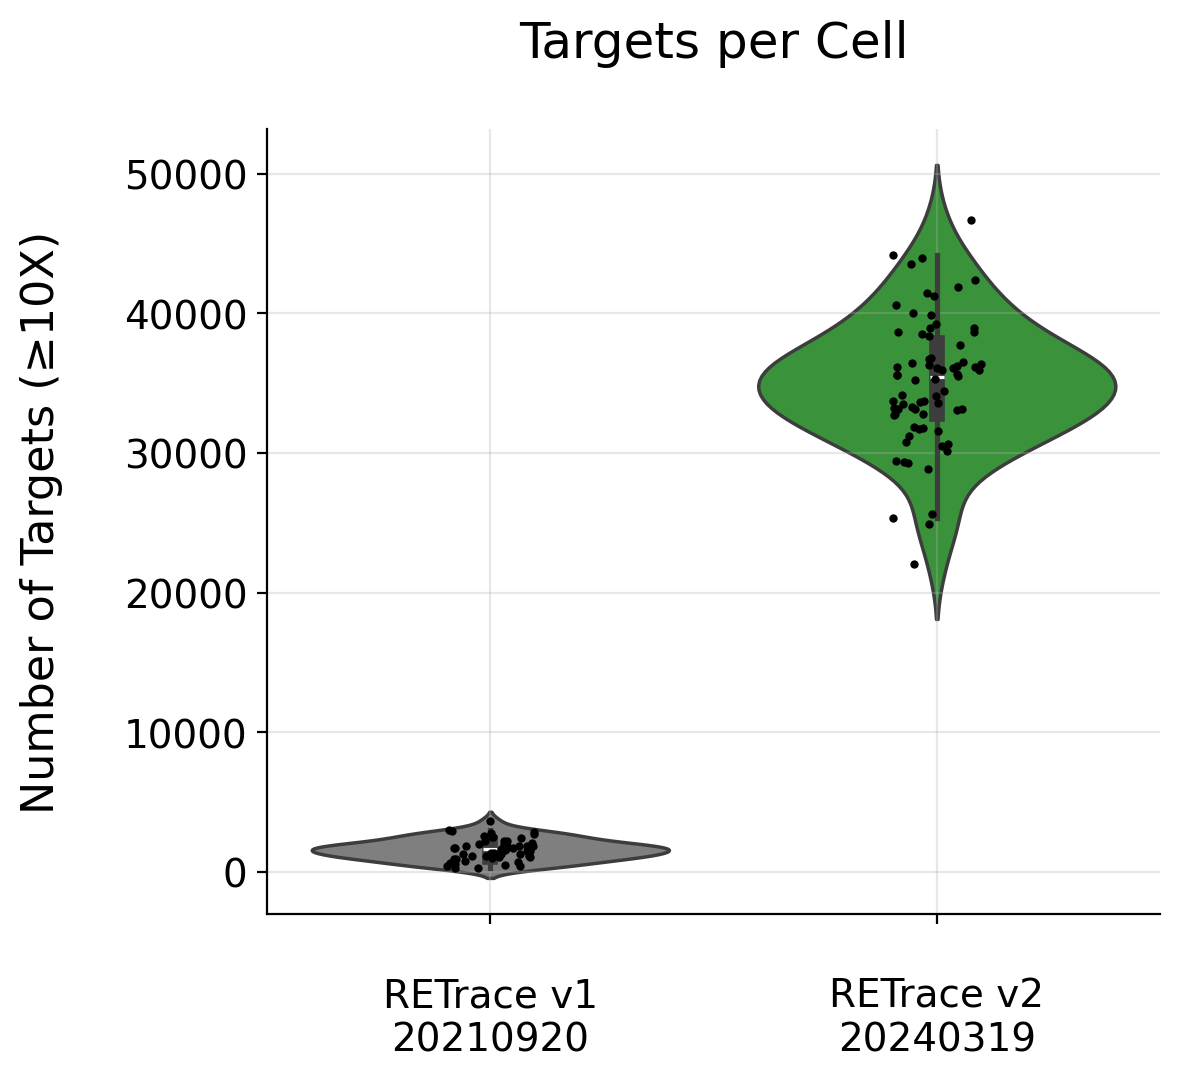

In [21]:
fig, ax = plt.subplots(figsize=(6,5.5), dpi=200)

sns.violinplot(x='group', y='ms_targets_with_min_reads', data=stats_data, hue='group', palette=['tab:gray', 'tab:green'])
sns.stripplot(x="group", y="ms_targets_with_min_reads", data=stats_data, color="black", ax=ax, size=3)

ax.set_xlabel("")
ax.set_title("Targets per Cell\n", fontsize=18)
ax.set_ylabel('Number of Targets (≥10X)\n', fontsize=16)
ax.tick_params(axis='both', labelsize=14)

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig("Fig1_Ntargets_per_cell.pdf")
plt.show()

In [22]:
stats_data.loc[:, ["group", "ms_targets_with_min_reads"]].groupby(["group"]).describe()

ms_targets_with_min_reads                             \
                                           count          mean          std   
group                                                                         
\nRETrace v1\n20210920                      54.0   1597.981481   769.188239   
\nRETrace v2\n20240319                      72.0  35038.486111  4648.216878   

                                                                      
                            min       25%      50%      75%      max  
group                                                                 
\nRETrace v1\n20210920    247.0   1085.75   1630.0   2068.5   3602.0  
\nRETrace v2\n20240319  22062.0  32758.50  35404.0  37891.5  46681.0